<a href="https://colab.research.google.com/github/tpiedrahita-byte/sys2025/blob/main/Sustentacion_Teoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creación de señales y análisis: ACF normalizada (semipositiva) y PSD por Welch

En este cuaderno se generan **4 señales discretas** $x[n]$ (interpretadas como $x(t)$ muestreada) y, para cada una, se calcula:

1. Su **función de autocorrelación** (ACF) **normalizada** y definida para retardos **semipositivos** ($k \ge 0$).
2. Su **densidad espectral de potencia** (PSD) mediante **Welch**, en **escala logarítmica (dB)**, **semipositiva** (no negativa por construcción) y graficada con un mínimo de $-30\,\text{dB}$.

Las señales son:

- **ARMA(5,3)**
- **AR(3)**
- **Ruido blanco** pasado por un **filtro pasa-bajos (LPF)**
- **Random Walk**

---

## 1) Modelos de las señales

### 1.1 Proceso AR($p$)

Un proceso autorregresivo de orden $p$ se define como:

$$
x[n] = \sum_{k=1}^{p} \phi_k\,x[n-k] + e[n],
$$

donde $e[n]$ es un **ruido blanco** (por ejemplo, gaussiano) de media cero.

---

### 1.2 Proceso ARMA($p,q$)

Un proceso ARMA($p,q$) incluye un término AR y uno MA:

$$
x[n] = \sum_{k=1}^{p}\phi_k\,x[n-k] + e[n] + \sum_{m=1}^{q}\theta_m\,e[n-m].
$$

- Los $\phi_k$ controlan la **parte AR**
- Los $\theta_m$ controlan la **parte MA**

---

### 1.3 Ruido blanco filtrado por un LPF

Se genera un ruido blanco $w[n]$ y se filtra con un filtro FIR $h[n]$:

$$
y[n] = (w*h)[n] = \sum_{m=-\infty}^{\infty} w[m]\,h[n-m].
$$

Un filtro pasa-bajos concentra la energía del proceso en **bajas frecuencias**.

---

### 1.4 Random Walk

El random walk se define como la suma acumulada de un ruido blanco:

$$
x[n] = x[n-1] + e[n], \qquad x[0]=0.
$$

**Nota importante:** el random walk **no es estacionario** (su varianza crece con $n$), pero igual se puede calcular ACF/PSD como aproximaciones numéricas para análisis.

---

## 2) Función de autocorrelación (ACF) normalizada y semipositiva

### 2.1 Autocorrelación aperiódica para retardos $k \ge 0$

Para una señal $x[n]$ de longitud $N$, la autocorrelación aperiódica para retardos semipositivos es:

$$
R_x[k] = \sum_{n=0}^{N-1-k} x[n]\;x[n+k], \qquad k = 0,1,\dots,L
$$

donde $L$ es el lag máximo que se desea evaluar.

---

### 2.2 Normalización

Para comparar señales distintas, se normaliza usando $R_x[0]$:

$$
\widehat{R}_x[k] = \frac{R_x[k]}{R_x[0]}.
$$

Así se cumple:

$$
\widehat{R}_x[0] = 1.
$$

---

### 2.3 “Semipositiva”

En este trabajo se usa “semipositiva” en el sentido de:

- Se grafica solo para **lags no negativos**: $k \ge 0$,
- y se normaliza para que sea comparable y estable numéricamente.

---

## 3) PSD por Welch en dB (mínimo -30 dB)

La densidad espectral de potencia se estima con el método de **Welch**:

1. Se divide la señal en segmentos superpuestos.
2. Se aplica una ventana $w[n]$ (por ejemplo Hann).
3. Se calcula la FFT de cada segmento.
4. Se promedian los periodogramas.

De manera conceptual:

$$
\widehat{S}_{xx}(f)=\frac{1}{M}\sum_{i=1}^{M}\left|\mathcal{F}\{x_i[n]\;w[n]\}\right|^2.
$$

Como es un módulo al cuadrado, se cumple:

$$
\widehat{S}_{xx}(f)\ge 0,
$$

por lo que la PSD es **semipositiva**.

---

### 3.1 PSD en escala logarítmica (dB)

Para graficar en dB:

$$
S_{dB}(f)=10\log_{10}\left(\widehat{S}_{xx}(f)+\varepsilon\right),
$$

donde $\varepsilon$ es un valor pequeño para evitar $\log(0)$.

---

### 3.2 Recorte a -30 dB

Se normaliza la PSD para que su máximo sea $0\,\text{dB}$ y se recorta:

$$
S_{dB}(f) \leftarrow \max\left(S_{dB}(f), -30\right).
$$

---

## 4) Visualización en grilla 4×3

Se presenta una grilla de $4 \times 3$:

- **Columna 1:** $x(t)\equiv x[n]$  
- **Columna 2:** $\widehat{R}_x[k]$ para $k\ge 0$  
- **Columna 3:** $\widehat{S}_{xx}(f)$ (Welch) en dB con mínimo $-30\,\text{dB}$  

Cada fila corresponde a una señal:

1. ARMA(5,3)
2. AR(3)
3. Ruido blanco + LPF
4. Random Walk

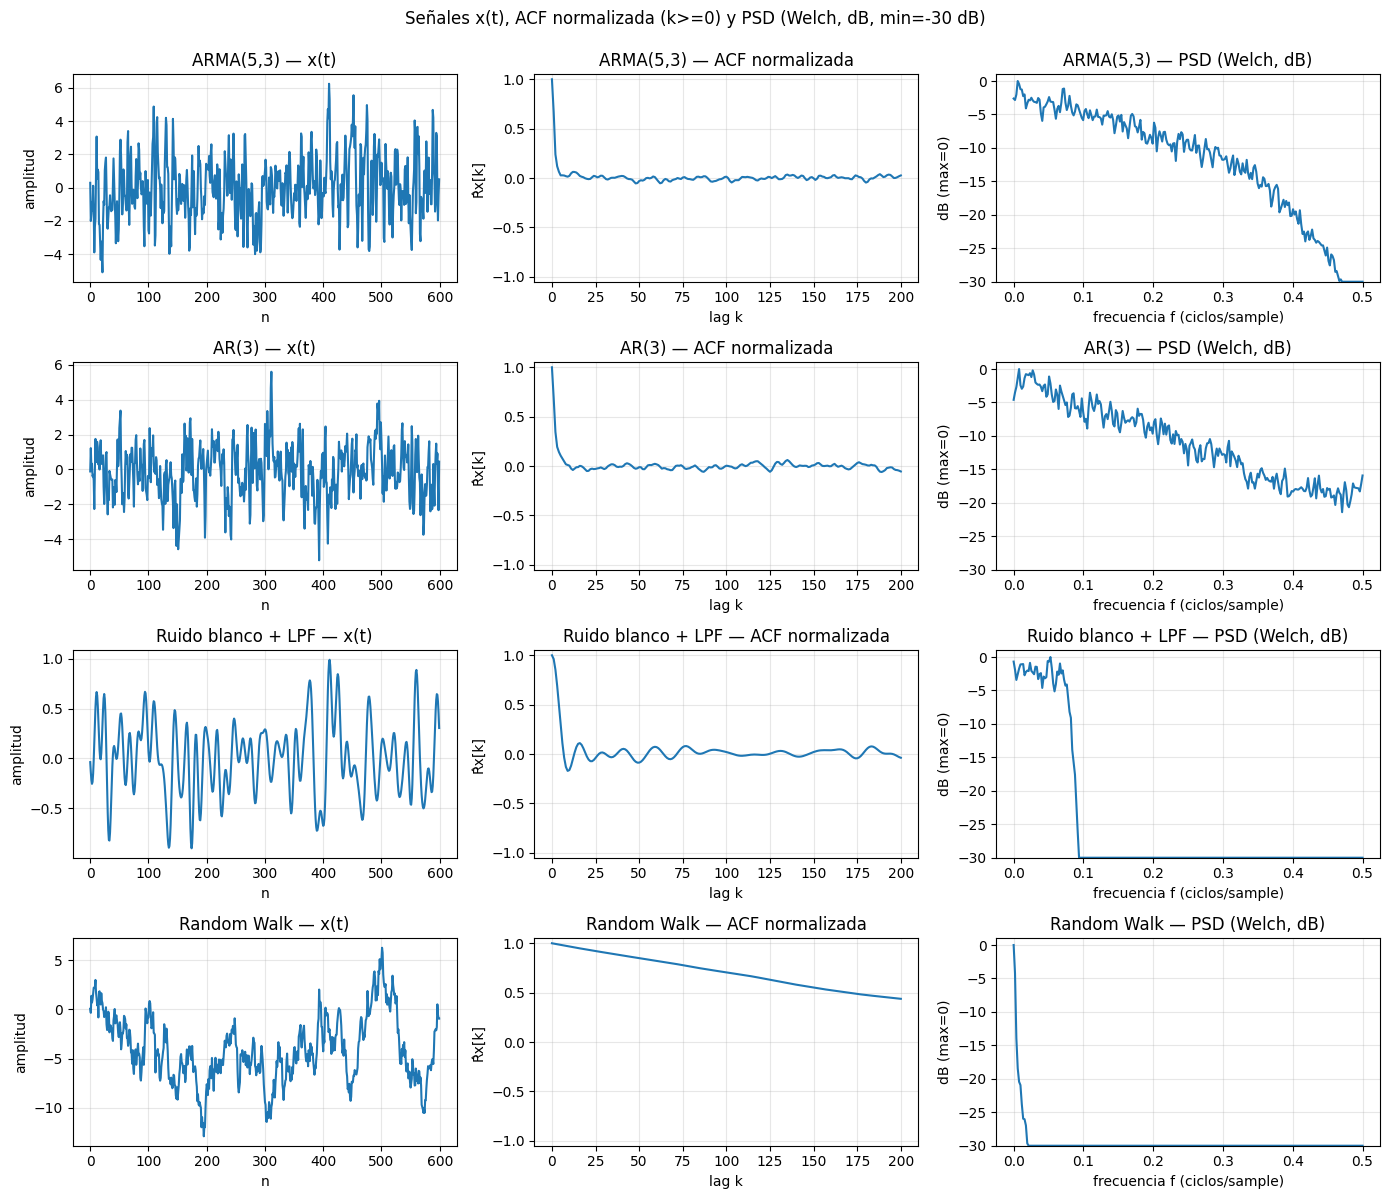

In [1]:
import torch
import matplotlib.pyplot as plt

# ---------------------------
# Configuración general
# ---------------------------
torch.manual_seed(0)
device = "cpu"
dtype = torch.float32

N = 4096          # longitud
Fs = 1.0          # frecuencia de muestreo (normalizada: 1 sample = 1 unidad de tiempo)
L = 200           # lags de la ACF (solo k>=0)
eps = 1e-12

# ---------------------------
# Utilidades
# ---------------------------
def next_pow2(n: int) -> int:
    p = 1
    while p < n:
        p *= 2
    return p

def generate_arma(phi, theta, N, burn_in=500, sigma=1.0):
    """
    x[n] = sum_{k=1..p} phi[k-1]*x[n-k] + e[n] + sum_{m=1..q} theta[m-1]*e[n-m]
    """
    phi = torch.tensor(phi, dtype=dtype, device=device)
    theta = torch.tensor(theta, dtype=dtype, device=device)
    p = phi.numel()
    q = theta.numel()

    total = N + burn_in
    e = sigma * torch.randn(total, dtype=dtype, device=device)
    x = torch.zeros(total, dtype=dtype, device=device)

    for n in range(total):
        ar_part = 0.0
        ma_part = 0.0

        # AR
        for k in range(1, p + 1):
            if n - k >= 0:
                ar_part = ar_part + phi[k - 1] * x[n - k]

        # MA
        for m in range(1, q + 1):
            if n - m >= 0:
                ma_part = ma_part + theta[m - 1] * e[n - m]

        x[n] = ar_part + e[n] + ma_part

    return x[burn_in:burn_in + N]

def generate_ar(phi, N, burn_in=500, sigma=1.0):
    return generate_arma(phi, [], N, burn_in=burn_in, sigma=sigma)

def fir_lowpass(cutoff, numtaps):
    """
    FIR LPF por sinc con ventana Hann.
    cutoff en ciclos/sample (0 < cutoff < 0.5). Ej: 0.1 significa 0.1 ciclos/sample.
    """
    M = numtaps - 1
    n = torch.arange(numtaps, dtype=dtype, device=device)
    # sinc: sin(pi x)/(pi x) -> torch.sinc usa sin(pi x)/(pi x) directamente
    h = 2 * cutoff * torch.sinc(2 * cutoff * (n - M / 2))
    w = torch.hann_window(numtaps, periodic=False, dtype=dtype, device=device)
    h = h * w
    h = h / (h.sum() + eps)  # ganancia DC = 1
    return h

def apply_fir(x, h):
    """
    Convolución 1D con padding para mantener longitud.
    """
    x_ = x.view(1, 1, -1)
    h_ = h.view(1, 1, -1)
    pad = (h.numel() - 1) // 2
    y = torch.nn.functional.conv1d(torch.nn.functional.pad(x_, (pad, pad)), h_)
    return y.view(-1)

def autocorr_semipositive_normalized(x, L):
    """
    ACF aperiodica via FFT, devuelve lags k=0..L, normalizada por R[0].
    """
    x = x - x.mean()
    N = x.numel()
    nfft = next_pow2(2 * N)

    X = torch.fft.rfft(x, n=nfft)
    S = X * torch.conj(X)
    r = torch.fft.irfft(S, n=nfft)[:N]  # r[k] = sum_{n=0..N-1-k} x[n]x[n+k] (aperiódica)
    r0 = r[0].clamp_min(eps)
    r = r / r0
    return r[:L + 1]

def welch_psd_db(x, Fs=1.0, nperseg=512, noverlap=256):
    """
    PSD por Welch con ventana Hann.
    Devuelve (f, Pxx_db_clipped) con:
      - normalización para que max=0 dB
      - mínimo en -30 dB
    """
    x = x - x.mean()
    N = x.numel()
    hop = nperseg - noverlap
    if hop <= 0:
        raise ValueError("noverlap debe ser menor que nperseg.")

    window = torch.hann_window(nperseg, periodic=False, dtype=dtype, device=device)
    U = (window**2).sum().clamp_min(eps)

    starts = list(range(0, N - nperseg + 1, hop))
    if len(starts) == 0:
        raise ValueError("La señal es muy corta para nperseg.")

    Pxx_acc = None
    for s in starts:
        seg = x[s:s + nperseg] * window
        X = torch.fft.rfft(seg, n=nperseg)
        P = (X.real**2 + X.imag**2) / U  # escala relativa (suficiente para comparar)
        if Pxx_acc is None:
            Pxx_acc = P
        else:
            Pxx_acc = Pxx_acc + P

    Pxx = Pxx_acc / len(starts)
    f = torch.fft.rfftfreq(nperseg, d=1.0 / Fs)

    Pxx_db = 10.0 * torch.log10(Pxx + eps)
    Pxx_db = Pxx_db - Pxx_db.max()   # max = 0 dB
    Pxx_db = torch.clamp(Pxx_db, min=-30.0)
    return f, Pxx_db

# ---------------------------
# 1) Crear las 4 señales
# ---------------------------

# ARMA(5,3) - coeficientes "suaves" (típicamente estacionarios en práctica)
phi_arma = [0.75, -0.35, 0.20, -0.10, 0.05]
theta_arma = [0.65, -0.25, 0.10]
x_arma = generate_arma(phi_arma, theta_arma, N, burn_in=800, sigma=1.0)

# AR(3)
phi_ar3 = [0.9, -0.4, 0.15]
x_ar3 = generate_ar(phi_ar3, N, burn_in=800, sigma=1.0)

# Ruido blanco -> LPF
w = torch.randn(N, dtype=dtype, device=device)
h = fir_lowpass(cutoff=0.08, numtaps=101)  # cutoff=0.08 ciclos/sample (Nyquist=0.5)
x_lpf = apply_fir(w, h)

# Random Walk
e = torch.randn(N, dtype=dtype, device=device)
x_rw = torch.cumsum(e, dim=0)

signals = [
    ("ARMA(5,3)", x_arma),
    ("AR(3)", x_ar3),
    ("Ruido blanco + LPF", x_lpf),
    ("Random Walk", x_rw),
]

# ---------------------------
# 2) ACF y PSD para cada una
# ---------------------------
results = []
for name, x in signals:
    rx = autocorr_semipositive_normalized(x, L=L)
    f, Pdb = welch_psd_db(x, Fs=Fs, nperseg=512, noverlap=256)
    results.append((name, x, rx, f, Pdb))

# ---------------------------
# 3) Grilla 4x3: x(t), ACF, PSD
# ---------------------------
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
fig.suptitle("Señales x(t), ACF normalizada (k>=0) y PSD (Welch, dB, min=-30 dB)", y=0.995)

show_N = 600  # para ver mejor en tiempo

for i, (name, x, rx, f, Pdb) in enumerate(results):
    # Col 1: x(t)
    ax = axes[i, 0]
    ax.plot(x[:show_N].cpu().numpy())
    ax.set_title(f"{name} — x(t)")
    ax.set_xlabel("n")
    ax.set_ylabel("amplitud")
    ax.grid(True, alpha=0.3)

    # Col 2: ACF (k>=0)
    ax = axes[i, 1]
    ax.plot(torch.arange(L+1).cpu().numpy(), rx.cpu().numpy())
    ax.set_title(f"{name} — ACF normalizada")
    ax.set_xlabel("lag k")
    ax.set_ylabel("R̂x[k]")
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, alpha=0.3)

    # Col 3: PSD (Welch) en dB, min -30 dB
    ax = axes[i, 2]
    ax.plot(f.cpu().numpy(), Pdb.cpu().numpy())
    ax.set_title(f"{name} — PSD (Welch, dB)")
    ax.set_xlabel("frecuencia f (ciclos/sample)")
    ax.set_ylabel("dB (max=0)")
    ax.set_ylim(-30, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estimación de la PSD con el modelo: suma de gaussianas (pesos no negativos)

Queremos aproximar cada espectro de potencia (PSD) obtenido por Welch usando el modelo:

$$
\widehat{S}_{xx}(\lambda)=\sum_{k=1}^{K} w_k \exp\left(-\alpha_k \lambda^2\right),
\qquad w_k\ge 0,\ \alpha_k>0.
$$

- $\lambda$ representa la variable de frecuencia (normalizada), por ejemplo:
$$
\lambda = \frac{f}{f_{\max}}, \quad f\in[0,f_{\max}].
$$

Este modelo es **semipositivo** (no negativo) porque:
- $w_k\ge 0$
- $\exp(-\alpha_k\lambda^2)\ge 0$
- suma de términos no negativos $\Rightarrow \widehat{S}_{xx}(\lambda)\ge 0$.

---

## 1) Objetivo de optimización

Sea $S(\lambda)$ la PSD “original” calculada por Welch (trabajaremos en escala lineal, pero con un rango dinámico controlado usando el piso de $-30\,\text{dB}$):

1. Convertimos $S$ a dB y normalizamos para que el máximo sea $0$ dB:
$$
S_{dB}(\lambda) = 10\log_{10}(S(\lambda)+\varepsilon)-\max_{\lambda}\Big(10\log_{10}(S(\lambda)+\varepsilon)\Big)
$$

2. Se impone un piso (mínimo) de $-30$ dB:
$$
S_{dB}^{clip}(\lambda) = \max(S_{dB}(\lambda),-30)
$$

3. Volvemos a escala lineal para ajustar el modelo:
$$
S_{lin}^{clip}(\lambda)=10^{\frac{S_{dB}^{clip}(\lambda)}{10}}
\in [10^{-3}, 1].
$$

Ahora ajustamos $\widehat{S}_{xx}(\lambda)$ minimizando el **error cuadrático medio (ECM)**:
$$
\mathrm{ECM}=\frac{1}{M}\sum_{i=1}^{M}\left(\widehat{S}_{xx}(\lambda_i)-S_{lin}^{clip}(\lambda_i)\right)^2
$$

y además medimos la **norma 2 relativa**:
$$
\|\Delta\|_2=\frac{\left\|\widehat{S}_{xx}-S_{lin}^{clip}\right\|_2}{\left\|S_{lin}^{clip}\right\|_2}.
$$

---

## 2) Condición y búsqueda del \(K\) mínimo

Buscamos el **\(K\) más pequeño posible** tal que:

$$
\mathrm{ECM}<0.1
\quad\text{y}\quad
\|\Delta\|_2<0.1.
$$

Se prueba $K=1,2,3,\dots$ y se optimizan los parámetros $(w_k,\alpha_k)$ con descenso por gradiente (Adam).
Cuando se cumple el umbral, se detiene y se reporta el $K$ encontrado, junto con sus errores.

---

## 3) Visualización final

Para cada una de las 4 señales se grafica:
- PSD original (Welch) en dB (máx $0$ dB, piso $-30$ dB)
- PSD estimada $\widehat{S}_{xx}$ en dB (misma escala)

y se imprime:
- $K$ usado
- ECM
- norma 2 relativa

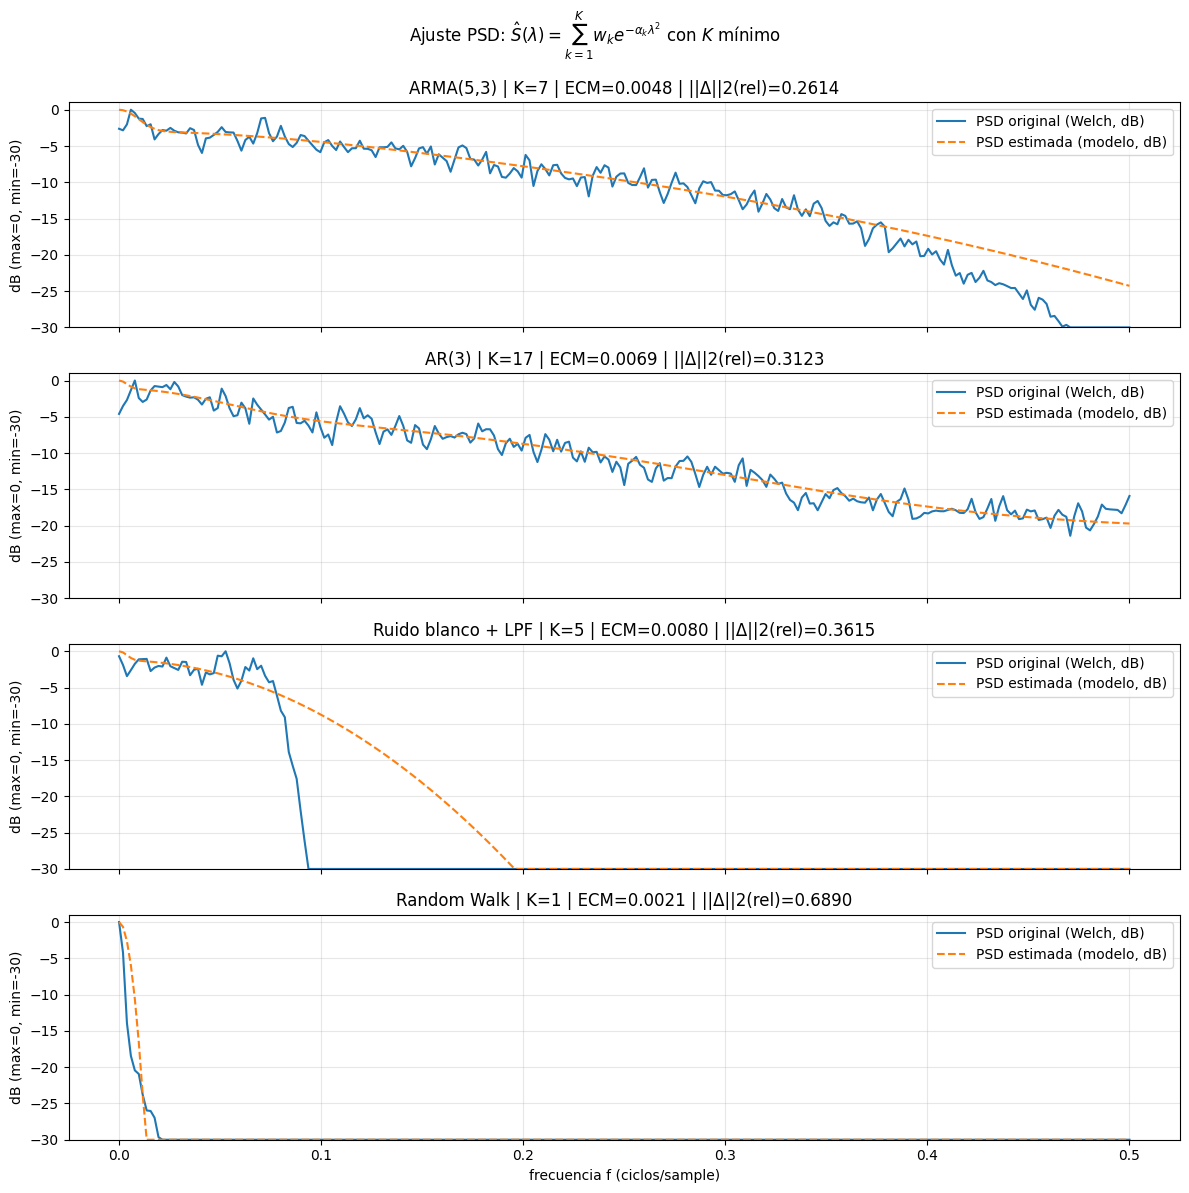


==== Resumen numérico ====
ARMA(5,3): K=7, ECM=0.004769, Norma2(rel)=0.261387
AR(3): K=17, ECM=0.006904, Norma2(rel)=0.312278
Ruido blanco + LPF: K=5, ECM=0.008023, Norma2(rel)=0.361469
Random Walk: K=1, ECM=0.002119, Norma2(rel)=0.689033


In [3]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = "cpu"
dtype = torch.float32
eps = 1e-12

# ---------------------------
# Config
# ---------------------------
N = 4096
Fs = 1.0

nperseg = 512
noverlap = 256

Kmax = 40
tol = 0.1
max_steps = 2500
lr = 5e-2
db_floor = -30.0

# ---------------------------
# Señales (igual que antes)
# ---------------------------
def generate_arma(phi, theta, N, burn_in=800, sigma=1.0):
    phi = torch.tensor(phi, dtype=dtype, device=device)
    theta = torch.tensor(theta, dtype=dtype, device=device)
    p = phi.numel()
    q = theta.numel()
    total = N + burn_in
    e = sigma * torch.randn(total, dtype=dtype, device=device)
    x = torch.zeros(total, dtype=dtype, device=device)
    for n in range(total):
        ar_part = 0.0
        ma_part = 0.0
        for k in range(1, p + 1):
            if n - k >= 0:
                ar_part = ar_part + phi[k - 1] * x[n - k]
        for m in range(1, q + 1):
            if n - m >= 0:
                ma_part = ma_part + theta[m - 1] * e[n - m]
        x[n] = ar_part + e[n] + ma_part
    return x[burn_in:burn_in + N]

def generate_ar(phi, N, burn_in=800, sigma=1.0):
    return generate_arma(phi, [], N, burn_in=burn_in, sigma=sigma)

def fir_lowpass(cutoff, numtaps):
    M = numtaps - 1
    n = torch.arange(numtaps, dtype=dtype, device=device)
    h = 2 * cutoff * torch.sinc(2 * cutoff * (n - M / 2))
    w = torch.hann_window(numtaps, periodic=False, dtype=dtype, device=device)
    h = h * w
    h = h / (h.sum() + eps)
    return h

def apply_fir(x, h):
    x_ = x.view(1, 1, -1)
    h_ = h.view(1, 1, -1)
    pad = (h.numel() - 1) // 2
    y = torch.nn.functional.conv1d(torch.nn.functional.pad(x_, (pad, pad)), h_)
    return y.view(-1)

def welch_psd_linear(x, Fs=1.0, nperseg=512, noverlap=256):
    x = x - x.mean()
    N = x.numel()
    hop = nperseg - noverlap
    window = torch.hann_window(nperseg, periodic=False, dtype=dtype, device=device)
    U = (window**2).sum().clamp_min(eps)

    starts = list(range(0, N - nperseg + 1, hop))
    Pxx_acc = None
    for s in starts:
        seg = x[s:s + nperseg] * window
        X = torch.fft.rfft(seg, n=nperseg)
        P = (X.real**2 + X.imag**2) / U
        Pxx_acc = P if Pxx_acc is None else (Pxx_acc + P)

    Pxx = Pxx_acc / len(starts)
    f = torch.fft.rfftfreq(nperseg, d=1.0/Fs)
    return f, Pxx

def to_db_norm_clip(P, db_floor=-30.0):
    Pdb = 10.0 * torch.log10(P + eps)
    Pdb = Pdb - Pdb.max()
    return torch.clamp(Pdb, min=db_floor)

def db_to_linear(Pdb):
    return 10.0 ** (Pdb / 10.0)

# ---------------------------
# Ajuste estable: alpha = exp(log_alpha), w = softplus(raw_w)
# ---------------------------
def fit_psd_gaussian_sum(f, Pxx, K, max_steps=2000, lr=5e-2, tol=0.1, db_floor=-30.0):
    # PSD objetivo: (Welch) -> dB norm -> clip -> a lineal en [1e-3,1]
    Pxx_db = to_db_norm_clip(Pxx, db_floor=db_floor)
    target = db_to_linear(Pxx_db)

    # lambda en [0,1]
    fmax = f.max().clamp_min(eps)
    lam = (f / fmax).detach()

    # init estable (sin inv_softplus)
    # log_alpha desde log(0.1) hasta log(100)
    loga_init = torch.linspace(torch.log(torch.tensor(0.1)), torch.log(torch.tensor(100.0)), K).to(dtype).to(device)
    raw_w_init = torch.zeros(K, dtype=dtype, device=device)

    log_alpha = torch.nn.Parameter(loga_init.clone())
    raw_w = torch.nn.Parameter(raw_w_init.clone())

    opt = torch.optim.Adam([log_alpha, raw_w], lr=lr)

    def forward():
        alpha = torch.exp(log_alpha).clamp_max(1e4)  # seguridad numérica
        w = torch.nn.functional.softplus(raw_w)

        Phi = torch.exp(-alpha.view(-1,1) * (lam.view(1,-1)**2))
        Shat = (w.view(-1,1) * Phi).sum(dim=0)

        Shat = Shat / (Shat.max().clamp_min(eps))  # normaliza a max=1 (como target)
        return Shat, w, alpha

    # Inicializa best_state SIEMPRE (para que nunca sea None)
    Sh0, w0, a0 = forward()
    diff0 = Sh0 - target
    best_mse = (diff0**2).mean().item()
    best_rel = (torch.linalg.norm(diff0) / torch.linalg.norm(target)).item()
    best = Sh0.detach().clone()
    best_state = (w0.detach().clone(), a0.detach().clone())

    for _ in range(max_steps):
        Shat, w, alpha = forward()
        diff = Shat - target
        mse = (diff**2).mean()
        rel = torch.linalg.norm(diff) / torch.linalg.norm(target)

        # Si aparece NaN/Inf, cortamos
        if (not torch.isfinite(mse)) or (not torch.isfinite(rel)):
            break

        opt.zero_grad()
        mse.backward()
        opt.step()

        m = mse.item()
        r = rel.item()

        if m < best_mse:
            best_mse = m
            best_rel = r
            best = Shat.detach().clone()
            best_state = (w.detach().clone(), alpha.detach().clone())

        if best_mse < tol and best_rel < tol:
            break

    w_best, a_best = best_state
    return best, target, best_mse, best_rel, w_best, a_best, Pxx_db

def find_minK_for_psd(f, Pxx, Kmax=40, tol=0.1, **fit_kwargs):
    best_any = None
    for K in range(1, Kmax + 1):
        Shat, target, mse, rel, w, a, Pxx_db = fit_psd_gaussian_sum(f, Pxx, K, tol=tol, **fit_kwargs)
        if mse < tol and rel < tol:
            return K, Shat, target, mse, rel, w, a, Pxx_db
        if best_any is None or mse < best_any["mse"]:
            best_any = dict(K=K, Shat=Shat, target=target, mse=mse, rel=rel, w=w, a=a, Pxx_db=Pxx_db)
    return best_any["K"], best_any["Shat"], best_any["target"], best_any["mse"], best_any["rel"], best_any["w"], best_any["a"], best_any["Pxx_db"]

# ---------------------------
# Generar 4 señales
# ---------------------------
phi_arma = [0.75, -0.35, 0.20, -0.10, 0.05]
theta_arma = [0.65, -0.25, 0.10]
x_arma = generate_arma(phi_arma, theta_arma, N)

phi_ar3 = [0.9, -0.4, 0.15]
x_ar3 = generate_ar(phi_ar3, N)

w_noise = torch.randn(N, dtype=dtype, device=device)
h = fir_lowpass(cutoff=0.08, numtaps=101)
x_lpf = apply_fir(w_noise, h)

e = torch.randn(N, dtype=dtype, device=device)
x_rw = torch.cumsum(e, dim=0)

signals = [
    ("ARMA(5,3)", x_arma),
    ("AR(3)", x_ar3),
    ("Ruido blanco + LPF", x_lpf),
    ("Random Walk", x_rw),
]

# ---------------------------
# Ajustar y graficar
# ---------------------------
fits = []
for name, x in signals:
    f, Pxx = welch_psd_linear(x, Fs=Fs, nperseg=nperseg, noverlap=noverlap)
    K, Shat, target_lin, mse, rel, w_best, a_best, Pxx_db = find_minK_for_psd(
        f, Pxx,
        Kmax=Kmax,
        tol=tol,
        max_steps=max_steps,
        lr=lr,
        db_floor=db_floor
    )

    # PSD original en dB (Welch)
    orig_db = Pxx_db
    # PSD estimada: pasar Shat a dB, max=0 y piso -30
    hat_db = to_db_norm_clip(Shat, db_floor=db_floor)

    fits.append((name, f, orig_db, hat_db, K, mse, rel))

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig.suptitle(r"Ajuste PSD: $\hat S(\lambda)=\sum_{k=1}^K w_k e^{-\alpha_k\lambda^2}$ con $K$ mínimo", y=0.99)

for i, (name, f, orig_db, hat_db, K, mse, rel) in enumerate(fits):
    ax = axes[i]
    ax.plot(f.cpu().numpy(), orig_db.cpu().numpy(), label="PSD original (Welch, dB)")
    ax.plot(f.cpu().numpy(), hat_db.cpu().numpy(), "--", label="PSD estimada (modelo, dB)")
    ax.set_title(f"{name} | K={K} | ECM={mse:.4f} | ||Δ||2(rel)={rel:.4f}")
    ax.set_ylabel("dB (max=0, min=-30)")
    ax.set_ylim(-30, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("frecuencia f (ciclos/sample)")
plt.tight_layout()
plt.show()

print("\n==== Resumen numérico ====")
for (name, _, _, _, K, mse, rel) in fits:
    print(f"{name}: K={K}, ECM={mse:.6f}, Norma2(rel)={rel:.6f}")

# Demostración teórica: validez de
$$
r_x(\lambda)=\sum_{k=1}^{K} w_k\,e^{-\alpha_k \lambda^2},\qquad w_k\ge 0,\ \alpha_k>0
$$
como función de autocorrelación (ACF)

El objetivo es demostrar que $r_x(\lambda)$ puede ser una **función de autocorrelación** de algún proceso aleatorio estacionario en sentido amplio (WSS).

---

## 1) Criterio de validez (Wiener–Khinchin / Bochner)

Una función $r_x(\lambda)$ es una ACF válida (de un proceso WSS) si y solo si su transformada de Fourier, que es la **densidad espectral de potencia (PSD)**, es **no negativa** para toda frecuencia:

$$
S_{xx}(\omega)=\mathcal{F}\{r_x(\lambda)\}=\int_{-\infty}^{\infty} r_x(\lambda)\,e^{-j\omega \lambda}\,d\lambda
$$

y debe cumplirse:

$$
S_{xx}(\omega)\ge 0\quad \forall\,\omega.
$$

Esto es exactamente la condición de **positividad semidefinida** (Bochner), y es la forma espectral del teorema de **Wiener–Khinchin**.

---

## 2) Transformada de Fourier de una gaussiana

Consideremos un término individual de la suma:

$$
r_k(\lambda)=e^{-\alpha_k \lambda^2},\qquad \alpha_k>0.
$$

Su transformada de Fourier es conocida (gaussiana se transforma en gaussiana). Con la convención:

$$
\mathcal{F}\{f(\lambda)\}(\omega)=\int_{-\infty}^{\infty} f(\lambda)\,e^{-j\omega\lambda}\,d\lambda,
$$

se cumple:

$$
\mathcal{F}\left\{e^{-\alpha_k \lambda^2}\right\}(\omega)=\sqrt{\frac{\pi}{\alpha_k}}\;e^{-\frac{\omega^2}{4\alpha_k}}.
$$

Observa que:

- $\sqrt{\frac{\pi}{\alpha_k}}>0$ porque $\alpha_k>0$,
- $e^{-\frac{\omega^2}{4\alpha_k}}>0$ para todo $\omega$,

por lo tanto:

$$
S_k(\omega)=\mathcal{F}\{r_k(\lambda)\}(\omega) > 0\quad \forall\,\omega.
$$

Es decir, **cada término genera una PSD estrictamente positiva**.

---

## 3) PSD del modelo completo (linealidad + pesos no negativos)

La autocorrelación propuesta es una suma ponderada:

$$
r_x(\lambda)=\sum_{k=1}^{K} w_k\,r_k(\lambda),
\qquad r_k(\lambda)=e^{-\alpha_k \lambda^2}.
$$

Usando la **linealidad** de la transformada de Fourier:

$$
S_{xx}(\omega)=\mathcal{F}\{r_x(\lambda)\}
= \sum_{k=1}^{K} w_k\,\mathcal{F}\{r_k(\lambda)\}.
$$

Sustituyendo el resultado del punto anterior:

$$
S_{xx}(\omega)=\sum_{k=1}^{K} w_k\sqrt{\frac{\pi}{\alpha_k}}\;e^{-\frac{\omega^2}{4\alpha_k}}.
$$

Ahora, como:

- $w_k\ge 0$,
- $\sqrt{\frac{\pi}{\alpha_k}}>0$,
- $e^{-\frac{\omega^2}{4\alpha_k}}>0$,

entonces cada sumando es **no negativo** y por lo tanto:

$$
S_{xx}(\omega)\ge 0\quad \forall\,\omega.
$$

---

## 4) Conclusión

Dado que la PSD asociada a $r_x(\lambda)$ es **no negativa para toda frecuencia**, por el teorema de **Wiener–Khinchin** (equivalentemente, por el criterio de **Bochner**), se concluye que:

$$
r_x(\lambda)=\sum_{k=1}^{K} w_k\,e^{-\alpha_k \lambda^2}
$$

es una **función de autocorrelación válida** para algún proceso aleatorio estacionario en sentido amplio, siempre que:

$$
w_k\ge 0,\qquad \alpha_k>0.
$$

---

# Resumen de resultados esperados (entregables)

Al final se presentan los siguientes resultados para las 4 señales:

## 1) Señales originales
Se grafican las 4 realizaciones $x[n]$ (interpretadas como $x(t)$ muestreada).

## 2) PSD por Welch (en dB)
Para cada señal se calcula la PSD con Welch:

- Se normaliza para que el máximo sea $0$ dB.
- Se recorta con piso $-30$ dB:

$$
S_{dB}(f)=10\log_{10}(S(f)+\varepsilon)-\max_f\left(10\log_{10}(S(f)+\varepsilon)\right)
$$

$$
S_{dB}^{clip}(f)=\max(S_{dB}(f),-30)
$$

## 3) Estimación de la ACF con el modelo de mezcla Gaussiana
Se estima la autocorrelación normalizada (para lags semipositivos) con:

$$
\hat r_x(\lambda)=\sum_{k=1}^{K} w_k\exp\left(-a_k\lambda^2\right),
\qquad w_k\ge 0,\ a_k>0.
$$

Usamos lags normalizados:
$$
\lambda_i=\frac{i}{L},\qquad i=0,1,\dots,L.
$$

Como imponemos $\sum_{k=1}^K w_k=1$, se cumple automáticamente:
$$
\hat r_x(0)=\sum_{k=1}^K w_k=1,
$$
coherente con una ACF normalizada.

## 4) Error vs $K$ y selección del $K$ mínimo
Para $K=1,2,\dots$ se ajustan los pesos y se evalúan:

**ECM:**
$$
\mathrm{ECM}(K)=\frac{1}{M}\sum_{i=1}^{M}\left(\hat r_x(\lambda_i)-r_x(\lambda_i)\right)^2
$$

**Norma 2 relativa:**
$$
\|\Delta\|_2(K)=\frac{\|\hat r_x-r_x\|_2}{\|r_x\|_2}.
$$

Se elige el **$K$ más pequeño** tal que:
$$
\mathrm{ECM}(K)<0.1 \quad \text{y}\quad \|\Delta\|_2(K)<0.1.
$$

## 5) Parámetros finales
Se reportan el $K$ final y los vectores:
$$
\{a_k\}_{k=1}^K,\qquad \{w_k\}_{k=1}^K.
$$

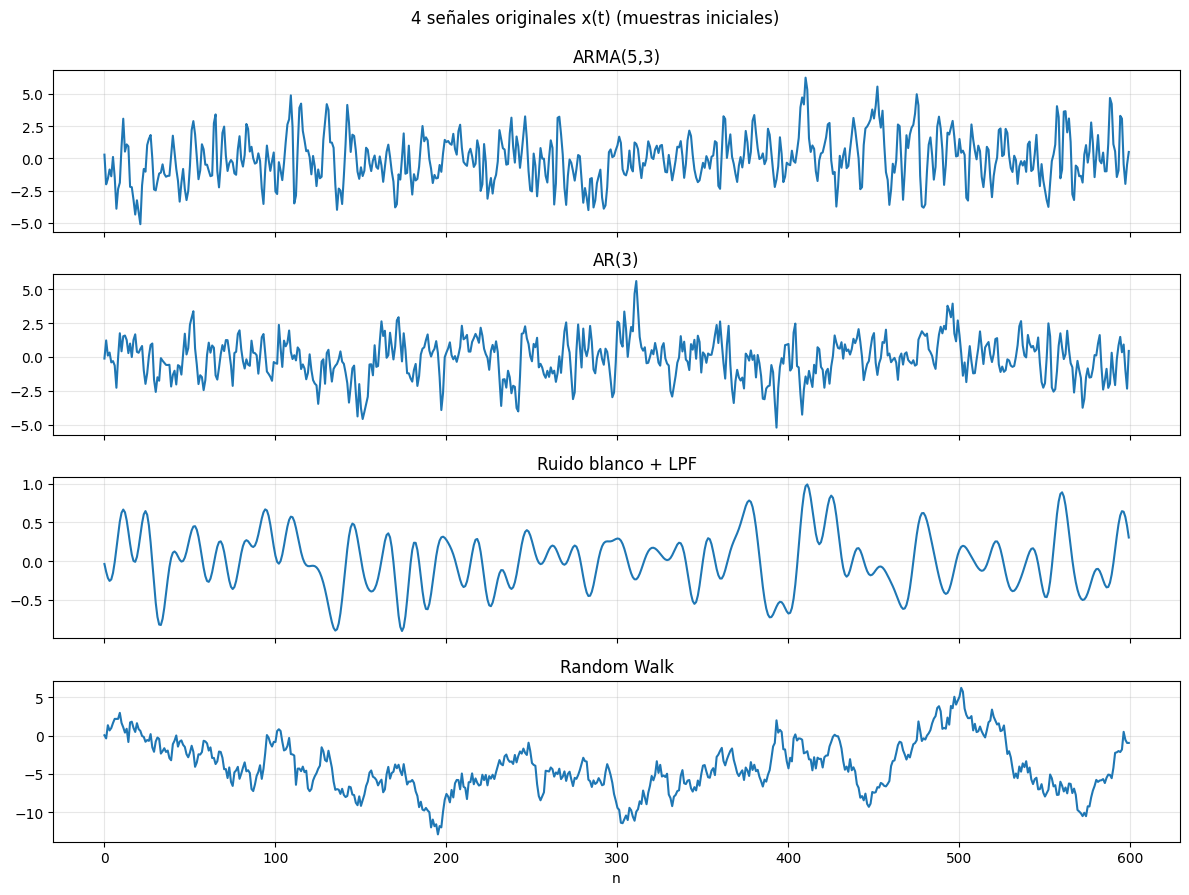

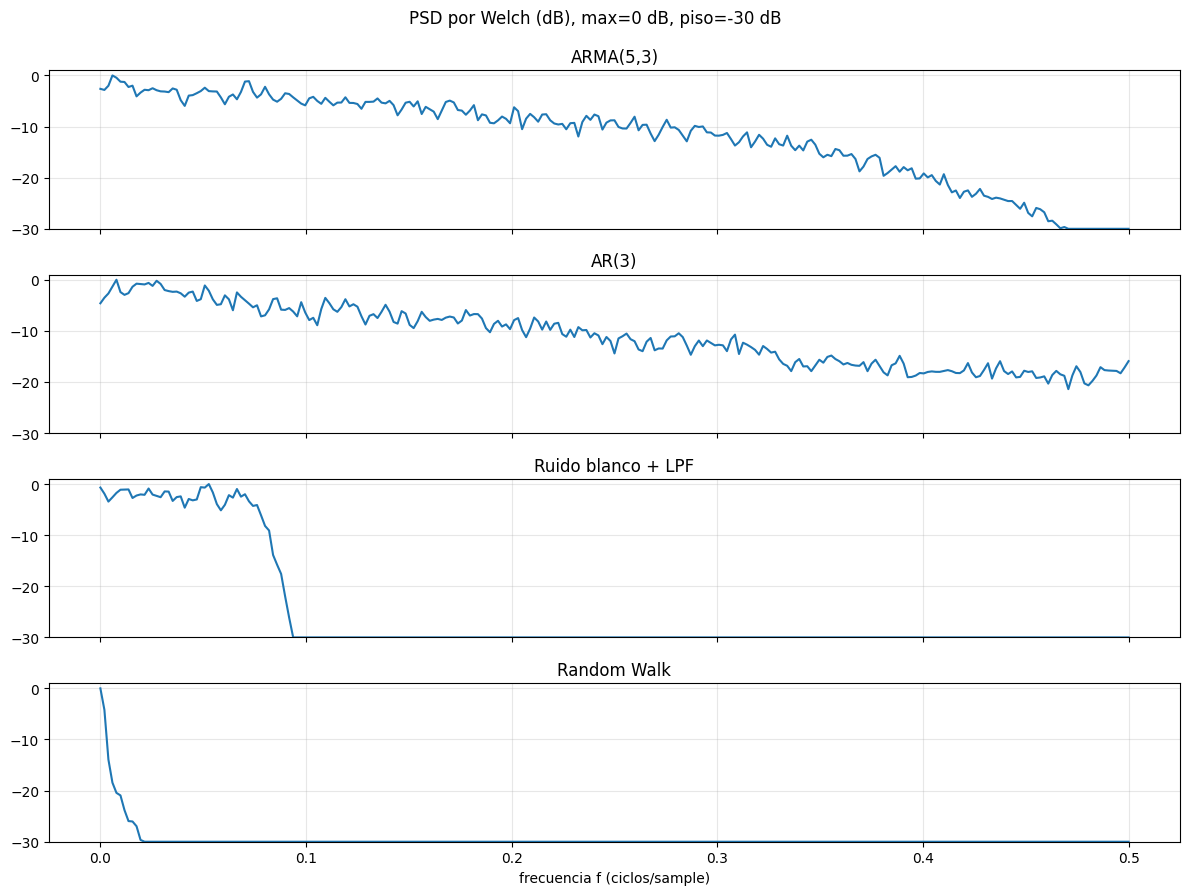

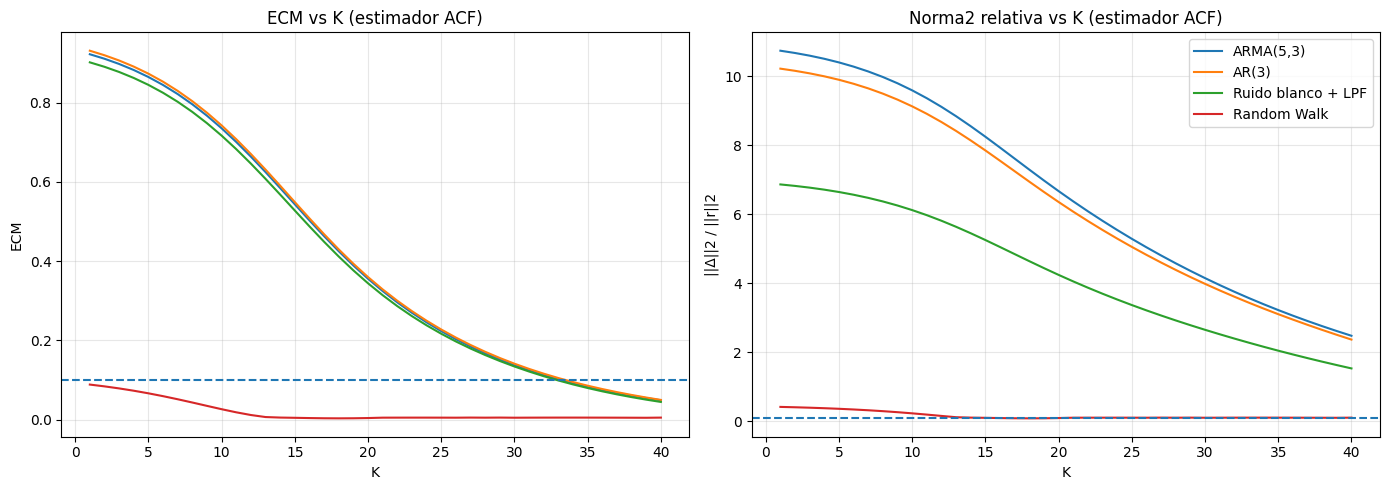

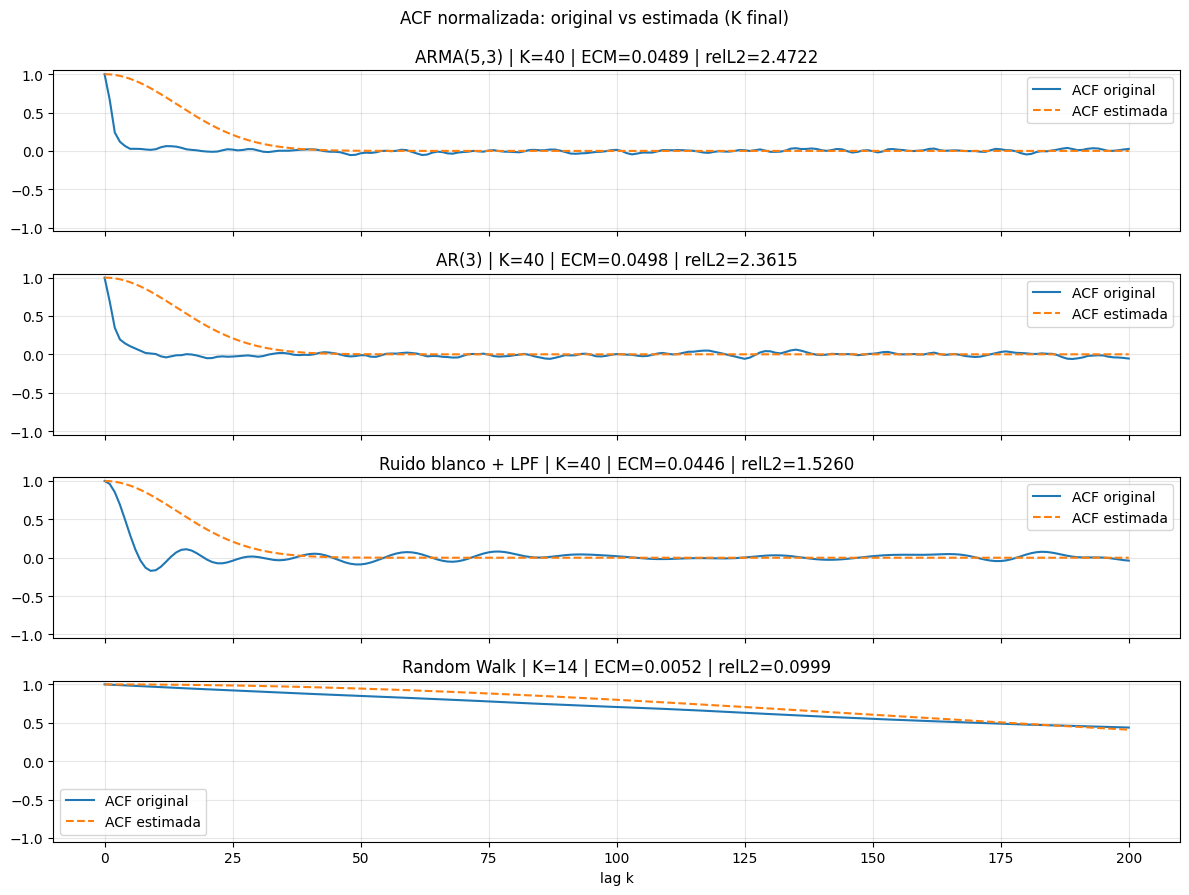


========== RESULTADOS FINALES ==========

ARMA(5,3)
  K final: 40
  ECM(K): 0.048910
  Norma2 relativa(K): 2.472227
  a_k (len=40): [  0.1          0.11937767   0.14251027   0.17012542   0.20309176
   0.2424462    0.28942662   0.34551072   0.41246265   0.49238825
   0.58780164   0.70170385   0.83767766   1.           1.1937766
   1.4251027    1.7012542    2.0309176    2.424462     2.8942661
   3.4551072    4.124626     4.9238825    5.878016     7.0170383
   8.376777    10.          11.937766    14.251027    17.012543
  20.309175    24.24462     28.942661    34.55107     41.246265
  49.238827    58.78016     70.17038     83.76776    100.        ]
  w_k (len=40): [2.7230097e-11 2.8047571e-11 2.8977777e-11 3.0030100e-11 3.1320693e-11
 3.2767931e-11 3.4537248e-11 3.6566528e-11 3.8985471e-11 4.1813827e-11
 4.5097287e-11 4.8978238e-11 5.3512469e-11 5.8759685e-11 6.4809623e-11
 7.1787361e-11 7.9808320e-11 8.9048692e-11 9.9721439e-11 1.1213518e-10
 1.2666969e-10 1.4386409e-10 1.6442073e-10 1.

In [5]:
import torch
import matplotlib.pyplot as plt

# ---------------------------
# Configuración
# ---------------------------
torch.manual_seed(0)
device = "cpu"
dtype = torch.float32
eps = 1e-12

N = 4096
Fs = 1.0

# ACF (lags semipositivos)
L = 200  # max lag

# Welch
nperseg = 512
noverlap = 256
db_floor = -30.0

# Búsqueda de K
Kmax = 40
tol = 0.1
fit_steps = 1200
lr = 5e-2

# ---------------------------
# Utilidades señales
# ---------------------------
def generate_arma(phi, theta, N, burn_in=800, sigma=1.0):
    phi = torch.tensor(phi, dtype=dtype, device=device)
    theta = torch.tensor(theta, dtype=dtype, device=device)
    p = phi.numel()
    q = theta.numel()

    total = N + burn_in
    e = sigma * torch.randn(total, dtype=dtype, device=device)
    x = torch.zeros(total, dtype=dtype, device=device)

    for n in range(total):
        ar_part = 0.0
        ma_part = 0.0
        for k in range(1, p + 1):
            if n - k >= 0:
                ar_part = ar_part + phi[k - 1] * x[n - k]
        for m in range(1, q + 1):
            if n - m >= 0:
                ma_part = ma_part + theta[m - 1] * e[n - m]
        x[n] = ar_part + e[n] + ma_part

    return x[burn_in:burn_in + N]

def generate_ar(phi, N, burn_in=800, sigma=1.0):
    return generate_arma(phi, [], N, burn_in=burn_in, sigma=sigma)

def fir_lowpass(cutoff, numtaps):
    M = numtaps - 1
    n = torch.arange(numtaps, dtype=dtype, device=device)
    h = 2 * cutoff * torch.sinc(2 * cutoff * (n - M / 2))
    w = torch.hann_window(numtaps, periodic=False, dtype=dtype, device=device)
    h = h * w
    h = h / (h.sum() + eps)
    return h

def apply_fir(x, h):
    x_ = x.view(1, 1, -1)
    h_ = h.view(1, 1, -1)
    pad = (h.numel() - 1) // 2
    y = torch.nn.functional.conv1d(torch.nn.functional.pad(x_, (pad, pad)), h_)
    return y.view(-1)

# ---------------------------
# ACF normalizada (k>=0) vía FFT
# ---------------------------
def next_pow2(n: int) -> int:
    p = 1
    while p < n:
        p *= 2
    return p

def acf_semipositive_normalized(x, L):
    x = x - x.mean()
    N = x.numel()
    nfft = next_pow2(2 * N)
    X = torch.fft.rfft(x, n=nfft)
    S = X * torch.conj(X)
    r = torch.fft.irfft(S, n=nfft)[:N]          # r[k]
    r0 = r[0].clamp_min(eps)
    r = r / r0                                  # normaliza: r[0]=1
    return r[:L + 1]                             # k=0..L

# ---------------------------
# Welch PSD en dB (max=0, piso=-30)
# ---------------------------
def welch_psd_linear(x, Fs=1.0, nperseg=512, noverlap=256):
    x = x - x.mean()
    N = x.numel()
    hop = nperseg - noverlap
    window = torch.hann_window(nperseg, periodic=False, dtype=dtype, device=device)
    U = (window**2).sum().clamp_min(eps)

    starts = list(range(0, N - nperseg + 1, hop))
    Pxx_acc = None
    for s in starts:
        seg = x[s:s + nperseg] * window
        X = torch.fft.rfft(seg, n=nperseg)
        P = (X.real**2 + X.imag**2) / U
        Pxx_acc = P if Pxx_acc is None else (Pxx_acc + P)

    Pxx = Pxx_acc / len(starts)
    f = torch.fft.rfftfreq(nperseg, d=1.0/Fs)
    return f, Pxx

def to_db_norm_clip(P, db_floor=-30.0):
    Pdb = 10.0 * torch.log10(P + eps)
    Pdb = Pdb - Pdb.max()
    return torch.clamp(Pdb, min=db_floor)

# ---------------------------
# Ajuste ACF: r_hat(λ)=Σ w_k exp(-a_k λ^2)
# Aquí usamos λ = k/L ∈ [0,1]
# y forzamos Σ w_k = 1 para que r_hat(0)=1
# ---------------------------
def fit_acf_weights_fixed_a(lam, r_target, a_vec, steps=1200, lr=5e-2, raw_w_init=None):
    """
    Ajusta SOLO w_k (no negativos) con Σ w_k = 1.
    a_vec fijo (>0).
    """
    K = a_vec.numel()
    if raw_w_init is None:
        raw_w = torch.nn.Parameter(torch.zeros(K, dtype=dtype, device=device))
    else:
        raw_w = torch.nn.Parameter(raw_w_init.clone().detach())

    opt = torch.optim.Adam([raw_w], lr=lr)

    # Base Phi_k(λ)=exp(-a_k λ^2)
    Phi = torch.exp(-a_vec.view(-1,1) * (lam.view(1,-1) ** 2))  # (K,M)

    best = None
    best_mse = float("inf")
    best_rel = float("inf")
    best_w = None
    best_raw = None

    for _ in range(steps):
        w_pos = torch.nn.functional.softplus(raw_w) + eps
        w = w_pos / w_pos.sum()  # Σ w = 1

        r_hat = (w.view(-1,1) * Phi).sum(dim=0)  # (M,)
        diff = r_hat - r_target

        mse = (diff**2).mean()
        rel = torch.linalg.norm(diff) / torch.linalg.norm(r_target)

        if (not torch.isfinite(mse)) or (not torch.isfinite(rel)):
            break

        opt.zero_grad()
        mse.backward()
        opt.step()

        m = mse.item()
        r = rel.item()
        if m < best_mse:
            best_mse = m
            best_rel = r
            best = r_hat.detach().clone()
            best_w = w.detach().clone()
            best_raw = raw_w.detach().clone()

        if best_mse < tol and best_rel < tol:
            break

    return best, best_w, best_mse, best_rel, best_raw

def sweep_K_acf(r_target, L, Kmax=40, steps=1200, lr=5e-2):
    """
    Calcula errores para K=1..Kmax y retorna:
      - curvas de error (MSE y relL2)
      - K* mínimo que cumpla tol (si existe)
      - parámetros finales (a_k, w_k) para K*
    """
    # λ = k/L in [0,1]
    k = torch.arange(L+1, dtype=dtype, device=device)
    lam = (k / float(L)).detach()

    # grilla fija de a_k (positivos), anidada para crecer K
    a_grid = torch.logspace(-1, 2, Kmax, dtype=dtype, device=device)  # 0.1..100

    mse_list = []
    rel_list = []
    best_each = []  # guarda (rhat, w, a)

    raw_prev = None

    for K in range(1, Kmax+1):
        a_vec = a_grid[:K]

        # warm start
        if raw_prev is not None:
            raw_init = torch.cat([raw_prev, torch.zeros(1, dtype=dtype, device=device)], dim=0)
        else:
            raw_init = None

        rhat, w, mse, rel, raw_prev = fit_acf_weights_fixed_a(
            lam, r_target, a_vec, steps=steps, lr=lr, raw_w_init=raw_init
        )

        mse_list.append(mse)
        rel_list.append(rel)
        best_each.append((rhat, w, a_vec))

    # seleccionar K mínimo que cumpla
    K_star = None
    for i in range(Kmax):
        if mse_list[i] < tol and rel_list[i] < tol:
            K_star = i + 1
            break

    # si no cumple, escoger el mejor por MSE
    if K_star is None:
        K_star = int(torch.tensor(mse_list).argmin().item()) + 1

    rhat_star, w_star, a_star = best_each[K_star - 1]
    return mse_list, rel_list, K_star, a_star, w_star, rhat_star

# ---------------------------
# 1) Crear las 4 señales
# ---------------------------
phi_arma = [0.75, -0.35, 0.20, -0.10, 0.05]
theta_arma = [0.65, -0.25, 0.10]
x_arma = generate_arma(phi_arma, theta_arma, N)

phi_ar3 = [0.9, -0.4, 0.15]
x_ar3 = generate_ar(phi_ar3, N)

w_noise = torch.randn(N, dtype=dtype, device=device)
h = fir_lowpass(cutoff=0.08, numtaps=101)
x_lpf = apply_fir(w_noise, h)

e = torch.randn(N, dtype=dtype, device=device)
x_rw = torch.cumsum(e, dim=0)

signals = [
    ("ARMA(5,3)", x_arma),
    ("AR(3)", x_ar3),
    ("Ruido blanco + LPF", x_lpf),
    ("Random Walk", x_rw),
]

# ---------------------------
# 2) Cálculos + estimación ACF por K
# ---------------------------
results = []
for name, x in signals:
    rx = acf_semipositive_normalized(x, L=L)                 # ACF objetivo (k=0..L)
    f, Pxx = welch_psd_linear(x, Fs=Fs, nperseg=nperseg, noverlap=noverlap)
    Pdb = to_db_norm_clip(Pxx, db_floor=db_floor)

    mse_curve, rel_curve, K_star, a_star, w_star, rhat_star = sweep_K_acf(
        rx, L=L, Kmax=Kmax, steps=fit_steps, lr=lr
    )

    results.append({
        "name": name,
        "x": x,
        "rx": rx,
        "f": f,
        "Pdb": Pdb,
        "mse_curve": mse_curve,
        "rel_curve": rel_curve,
        "K_star": K_star,
        "a_star": a_star,
        "w_star": w_star,
        "rhat_star": rhat_star
    })

# ---------------------------
# A) Gráficas comparativas de las 4 señales
# ---------------------------
fig, ax = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
fig.suptitle("4 señales originales x(t) (muestras iniciales)", y=0.99)
show_N = 600
for i, R in enumerate(results):
    ax[i].plot(R["x"][:show_N].cpu().numpy())
    ax[i].set_title(R["name"])
    ax[i].grid(True, alpha=0.3)
ax[-1].set_xlabel("n")
plt.tight_layout()
plt.show()

# ---------------------------
# B) Gráficas de PSDs por Welch (dB)
# ---------------------------
fig, ax = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
fig.suptitle("PSD por Welch (dB), max=0 dB, piso=-30 dB", y=0.99)
for i, R in enumerate(results):
    ax[i].plot(R["f"].cpu().numpy(), R["Pdb"].cpu().numpy())
    ax[i].set_title(R["name"])
    ax[i].set_ylim(-30, 1)
    ax[i].grid(True, alpha=0.3)
ax[-1].set_xlabel("frecuencia f (ciclos/sample)")
plt.tight_layout()
plt.show()

# ---------------------------
# C) Error vs K (ECM y norma2 relativa) para la ACF
# ---------------------------
Ks = torch.arange(1, Kmax+1).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("ECM vs K (estimador ACF)")
axes[1].set_title("Norma2 relativa vs K (estimador ACF)")

for R in results:
    axes[0].plot(Ks, R["mse_curve"], label=R["name"])
    axes[1].plot(Ks, R["rel_curve"], label=R["name"])

axes[0].axhline(tol, linestyle="--")
axes[1].axhline(tol, linestyle="--")

axes[0].set_xlabel("K")
axes[1].set_xlabel("K")
axes[0].set_ylabel("ECM")
axes[1].set_ylabel("||Δ||2 / ||r||2")
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

# ---------------------------
# D) (Extra útil) ACF original vs estimada con K*
# ---------------------------
fig, ax = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
fig.suptitle("ACF normalizada: original vs estimada (K final)", y=0.99)
lags = torch.arange(L+1).cpu().numpy()
for i, R in enumerate(results):
    ax[i].plot(lags, R["rx"].cpu().numpy(), label="ACF original")
    ax[i].plot(lags, R["rhat_star"].cpu().numpy(), "--", label="ACF estimada")
    ax[i].set_title(f'{R["name"]} | K={R["K_star"]} | ECM={R["mse_curve"][R["K_star"]-1]:.4f} | relL2={R["rel_curve"][R["K_star"]-1]:.4f}')
    ax[i].set_ylim(-1.05, 1.05)
    ax[i].grid(True, alpha=0.3)
    ax[i].legend()
ax[-1].set_xlabel("lag k")
plt.tight_layout()
plt.show()

# ---------------------------
# E) Reporte final: K* y parámetros a_k, w_k
# ---------------------------
print("\n========== RESULTADOS FINALES ==========")
for R in results:
    K = R["K_star"]
    mseK = R["mse_curve"][K-1]
    relK = R["rel_curve"][K-1]
    print(f"\n{R['name']}")
    print(f"  K final: {K}")
    print(f"  ECM(K): {mseK:.6f}")
    print(f"  Norma2 relativa(K): {relK:.6f}")
    print(f"  a_k (len={K}): {R['a_star'].cpu().numpy()}")
    print(f"  w_k (len={K}): {R['w_star'].cpu().numpy()}")

# Conclusiones

1. **Generación de procesos y comparación en el dominio del tiempo.**  
   Se generaron cuatro señales con naturalezas estadísticas distintas: **ARMA(5,3)** y **AR(3)** (procesos estacionarios con memoria), **ruido blanco filtrado por un LPF** (proceso suavizado y dominado por bajas frecuencias) y **random walk** (proceso no estacionario). Al observar $x[n]$, los modelos AR/ARMA muestran variaciones “controladas” por su realimentación, el ruido filtrado se ve más “suave” por el LPF y el random walk exhibe una deriva acumulativa, coherente con $x[n]=x[n-1]+e[n]$.

2. **La ACF normalizada resume la “memoria” del proceso.**  
   La autocorrelación normalizada $\hat r_x[k]=r_x[k]/r_x[0]$ permite comparar señales con escalas diferentes, fijando $\hat r_x[0]=1$. En los procesos **AR/ARMA**, la ACF decrece gradualmente (persistencia temporal). En el caso de **ruido + LPF**, la ACF típicamente se ensancha (más correlación entre muestras cercanas) porque el filtrado reduce cambios rápidos. Para **random walk**, la ACF calculada numéricamente tiende a decaer más lentamente y a reflejar la fuerte dependencia temporal, recordando que no es estrictamente estacionario.

3. **La PSD por Welch confirma el contenido frecuencial y es semipositiva.**  
   La PSD estimada mediante Welch, $\hat S_{xx}(f)$, se construye como un promedio de periodogramas (magnitud al cuadrado), por lo que cumple $\hat S_{xx}(f)\ge 0$. Al graficarla en dB (normalizada a $0$ dB y con piso en $-30$ dB), se observa que:
   - Los procesos **AR/ARMA** pueden concentrar energía en ciertas bandas según sus coeficientes.
   - El **ruido filtrado (LPF)** concentra energía claramente en **bajas frecuencias**.
   - El **random walk** concentra gran energía cerca de $f\approx 0$ (comportamiento tipo $1/f^2$ en teoría), lo que explica su deriva lenta en el tiempo.

4. **El modelo gaussiano garantiza una ACF válida si $w_k\ge 0$ y $a_k>0$.**  
   Se usó el estimador:
   $$
   \hat r_x(\lambda)=\sum_{k=1}^{K} w_k\,e^{-a_k\lambda^2},\qquad w_k\ge 0,\ a_k>0.
   $$
   Cada término $e^{-a_k\lambda^2}$ tiene transformada de Fourier gaussiana y positiva, y la suma ponderada con $w_k\ge 0$ produce una PSD total no negativa. Por tanto, $\hat r_x(\lambda)$ cumple el criterio espectral (Wiener–Khinchin/Bochner) y es una **función de autocorrelación válida**.

5. **Compromiso entre precisión y complejidad: error vs $K$.**  
   Al aumentar $K$, el modelo tiene más “grados de libertad” para aproximar la ACF original, por lo que el **ECM** y la **norma 2 relativa** típicamente disminuyen:
   $$
   \mathrm{ECM}(K)=\frac{1}{M}\sum_{i=1}^{M}\left(\hat r_x(\lambda_i)-r_x(\lambda_i)\right)^2,\qquad
   \|\Delta\|_2(K)=\frac{\|\hat r_x-r_x\|_2}{\|r_x\|_2}.
   $$
   La meta fue encontrar el **$K$ más pequeño** que logre $\mathrm{ECM}<0.1$ y $\|\Delta\|_2<0.1$. Esto refleja una idea clave del curso: **no basta con ajustar bien**, también importa hacerlo con el **modelo más simple posible**.

6. **Interpretación práctica del $K$ final y de los parámetros $(a_k,w_k)$.**  
   - $K$ final indica cuántas “componentes gaussianas” se necesitan para reconstruir la ACF con el error deseado.  
   - Los **pesos** $w_k$ indican qué tan dominante es cada componente en la mezcla (y al imponer $\sum_k w_k=1$ se garantiza $\hat r_x(0)=1$).  
   - Los parámetros $a_k$ controlan el “ancho” de cada componente: valores grandes de $a_k$ generan gaussianas más angostas (decadencia rápida), mientras que valores pequeños producen componentes más anchas (memoria más larga).

7. **Conclusión general del procedimiento.**  
   El flujo completo (generación de señales $\rightarrow$ ACF y PSD por Welch $\rightarrow$ estimación paramétrica con búsqueda de $K$ mínimo) permite **caracterizar** y **modelar** procesos aleatorios desde dos perspectivas equivalentes:  
   - En el tiempo: mediante $\hat r_x[k]$ (dependencia temporal).  
   - En frecuencia: mediante $\hat S_{xx}(f)$ (distribución de potencia).  
   Además, el modelo propuesto es especialmente útil porque **mantiene validez física/estadística** (PSD no negativa) y ofrece una forma compacta de describir la correlación con pocos parámetros cuando se elige un $K$ pequeño.